In [1]:
import pandas as pd

In [4]:
df=pd.read_excel('Telco_customer_churn.xlsx')


In [8]:
df.to_csv('telco_customer_churn.csv', index=False)

In [10]:
df=pd.read_csv('telco_customer_churn.csv')

In [11]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [13]:
df.shape

(7043, 33)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [15]:
#check for missing values
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [18]:
target='Churn Value'

In [27]:
# Make a copy to avoid SettingWithCopyWarning
df = df.copy()

columns_to_drop=[
    "CustomerID",
    "Count",
    "Country", "State", "City", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [28]:
#convert Total charges column to numeric column(It is currently a numeric 
#column but sometimes there might be some errors there, so - it is better to just do this.)
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors = 'coerce')

#drop any row where conversion failed
df=df.dropna(subset=['Total Charges'])

In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
le=LabelEncoder()
# Binary columns
binary_columns=[
'Gender', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing'
]
for col in binary_columns:
    df[col]=le.fit_transform(df[col])

# Multi-category columns
multi_cat_columns = [
    'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Payment Method'
]
for col in multi_cat_columns:
    df[col]=le.fit_transform(df[col])

#split into features (X) and target (y)
target='Churn Value'
y=df[target]
X=df.drop(target, axis=1)

#train test split
X_train,X_test,y_train,y_test,=train_test_split(X,y,test_size=0.2,random_state=42)

#Check dataset info
#print("Training features shape:", X_train.shape)
#print("Test features shape:", X_test.shape)
#print("\nFirst 5 rows of training data:\n", X_train.head())
#print("\nTarget distribution in training set:\n", y_train.value_counts())

In [47]:
#Let's train our model
#Train the logistics regression model
from sklearn.linear_model import LogisticRegression
#initialize the model
model=LogisticRegression(max_iter=1000, random_state=42)
#train the model
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [48]:
#i ran the below code because it didn't convert to numeric or maybe it did but it was showing as text(object)
#i ran the below code because the first model i trained gave an error, i mean the one above. 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Senior Citizen'] = le.fit_transform(df['Senior Citizen'])
#df.dtypes

In [49]:
#let us make predictions
y_pred=model.predict(X_test)

In [51]:
#Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("Classification Report:",classification_report(y_test,y_pred))

Accuracy: 0.8081023454157783
Confusion Matrix: [[908 104]
 [166 229]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.69      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.80      0.81      0.80      1407



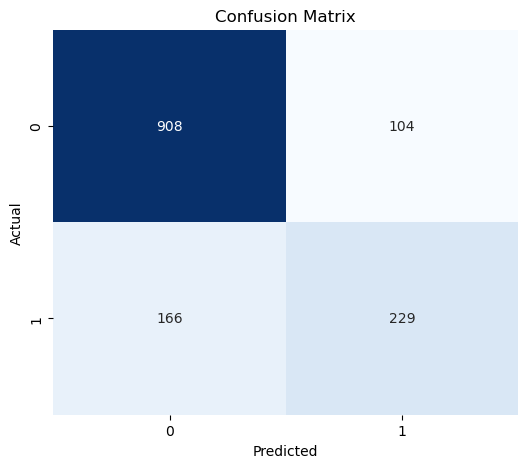

In [52]:
#let us visualize the confuison matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#confusion matrix
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [53]:
#show feature importance
#Logistic Regression lets us see which features influence churn the most via coefficients:
import pandas as pd
import numpy as np
#get feature names and coefficients
feature_importance=pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
# Sort by absolute impact
feature_importance['Abs_Coeff'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coeff', ascending=False)

# Show top 10 features
feature_importance.head(10)

,Feature,Coefficient,Abs_Coeff
3,Dependents,-1.502525,1.502525
14,Contract,-0.767091,0.767091
5,Phone Service,-0.729843,0.729843
15,Paperless Billing,0.421267,0.421267
2,Partner,0.340732,0.340732
8,Online Security,-0.242939,0.242939
11,Tech Support,-0.199590,0.199590
1,Senior Citizen,0.195157,0.195157
9,Online Backup,-0.148512,0.148512
7,Internet Service,0.110594,0.110594


/var/folders/vw/rynbknvs76n1g1w8qk2qy3dc0000gn/T/ipykernel_33206/1091840349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10), palette='viridis')


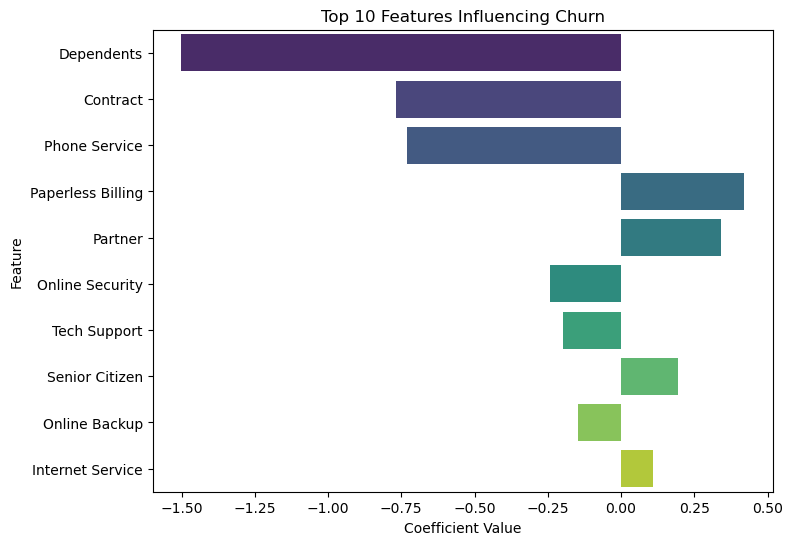

In [54]:
#Plot the top 10 features
plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title("Top 10 Features Influencing Churn")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [59]:
#let us upgrade the churn model with a random forest
#import and initialize the Random Forest
from sklearn.ensemble import RandomForestClassifier
#initiliaze the model
rf_model=RandomForestClassifier(
    n_estimators=100, # 100 trees
    random_state=42,
    max_depth=8, # This prevents overfitting
    class_weight='balanced' # This handles class imbalance
)

In [61]:
#let us now train the model
rf_model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, random_state=42)

In [62]:
#let us make predictions
y_pred_rf=rf_model.predict(X_test)

In [64]:
#Time to evaluate performance
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print("Random Forest Accuracy score:",accuracy_score(y_test,y_pred_rf))
print("Random Forest Confusion Matrix:",confusion_matrix(y_test,y_pred_rf))
print("Random Forest Classfication Report:",classification_report(y_test,y_pred_rf))

Random Forest Accuracy score: 0.7782515991471215
Random Forest Confusion Matrix: [[788 224]
 [ 88 307]]
Random Forest Classfication Report:               precision    recall  f1-score   support

           0       0.90      0.78      0.83      1012
           1       0.58      0.78      0.66       395

    accuracy                           0.78      1407
   macro avg       0.74      0.78      0.75      1407
weighted avg       0.81      0.78      0.79      1407



/var/folders/vw/rynbknvs76n1g1w8qk2qy3dc0000gn/T/ipykernel_33206/2806230761.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_features.head(10), palette='viridis')


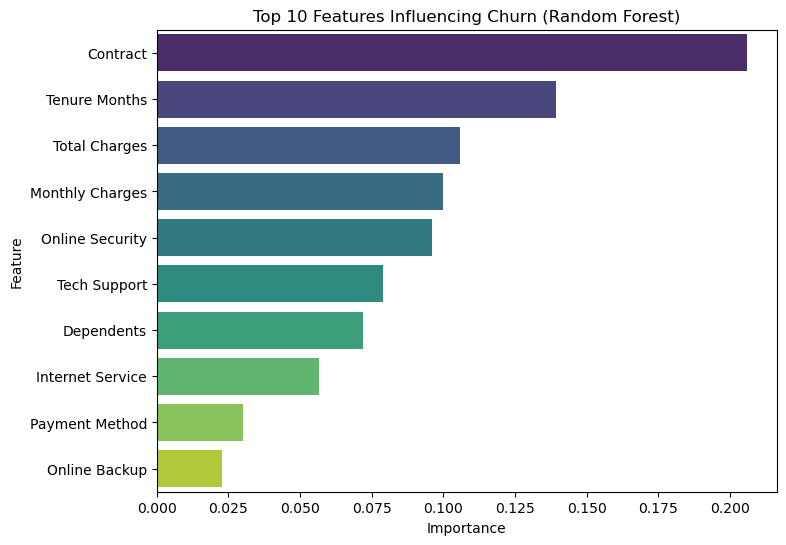

In [66]:
#Feature importance
#Random Forest lets you see which features matter most:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
rf_features = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
rf_features = rf_features.sort_values(by='Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=rf_features.head(10), palette='viridis')
plt.title("Top 10 Features Influencing Churn (Random Forest)")
plt.show()

In [67]:
#side-by-side comparison of Logistic Regression vs Random Forest
#Make predictions for both models(i didn't bother making predicitons again since i have done that earlier for both models)
from sklearn.metrics import accuracy_score, f1_score

# Accuracy
acc_lr = accuracy_score(y_test, y_pred)
acc_rf = accuracy_score(y_test, y_pred_rf)

# F1-score for churn (class 1)
f1_lr = f1_score(y_test, y_pred, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print(f"Logistic Regression -> Accuracy: {acc_lr:.3f}, F1-score (Churn): {f1_lr:.3f}")
print(f"Random Forest       -> Accuracy: {acc_rf:.3f}, F1-score (Churn): {f1_rf:.3f}")

Logistic Regression -> Accuracy: 0.808, F1-score (Churn): 0.629
Random Forest       -> Accuracy: 0.778, F1-score (Churn): 0.663


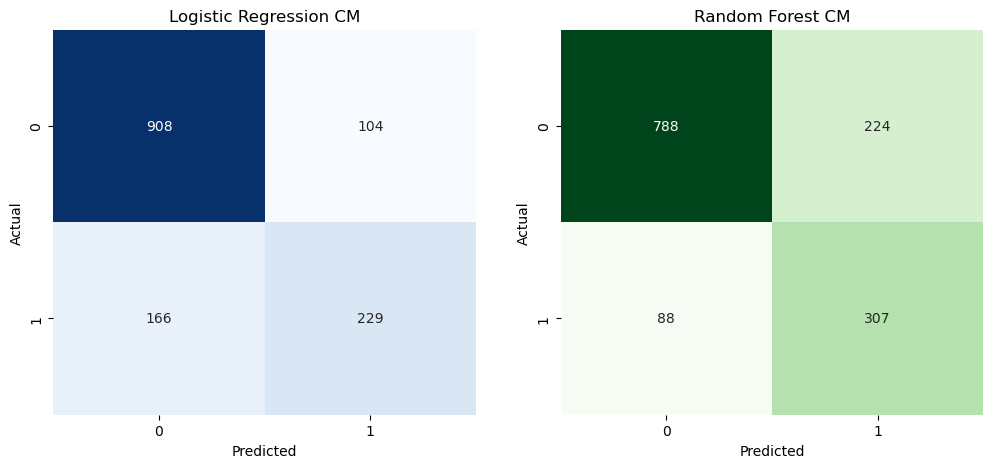

In [68]:
#Compare confusion matrices visually
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression CM
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title("Logistic Regression CM")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest CM
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title("Random Forest CM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.show()